# Chapter 16 — Support Vector Machines

**Goals**

- Visualize a linear SVM on a separable toy dataset; find the maximum-margin hyperplane.
- See the effect of $C$ on the soft margin.
- Use the **kernel trick** with `kernel='rbf'` to handle non-linear shapes (`make_moons`).
- Tune $C$ and $\gamma$ on Breast Cancer Wisconsin via grid-search CV.

Pair with `docs/09_svm.md`.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_classification, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
np.set_printoptions(precision=4, suppress=True)

## 2. Linear SVM on a 2D separable dataset

Plot the decision boundary, the margin lines, and highlight the support vectors.

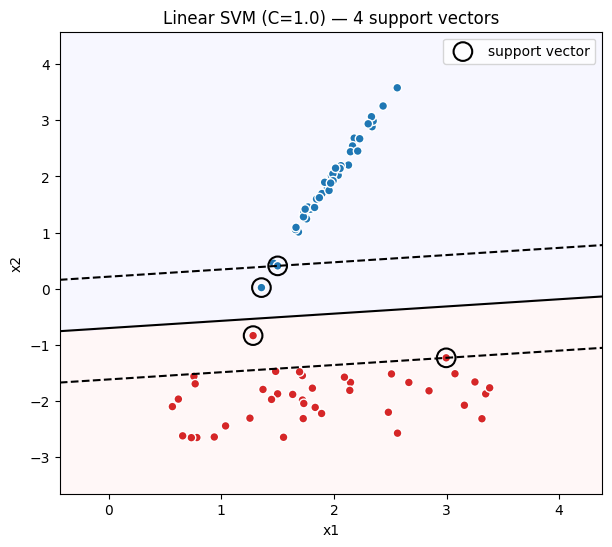

In [2]:
X, y = make_classification(
    n_samples=80, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=SEED,
)
y_pm = np.where(y == 0, -1, 1)  # ±1 labels, the SVM convention

svc = SVC(kernel='linear', C=1.0).fit(X, y_pm)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)
Z = svc.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z > 0, alpha=0.15, cmap=ListedColormap(['#ffcccc', '#ccccff']))
ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='black', linestyles=['--', '-', '--'])
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['tab:red', 'tab:blue']), edgecolor='white', s=40)
ax.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1],
           s=180, facecolors='none', edgecolors='black', linewidths=1.5, label='support vector')
ax.set_title(f'Linear SVM (C=1.0) — {len(svc.support_)} support vectors')
ax.legend(); ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.show()

## 3. Soft margin — effect of $C$

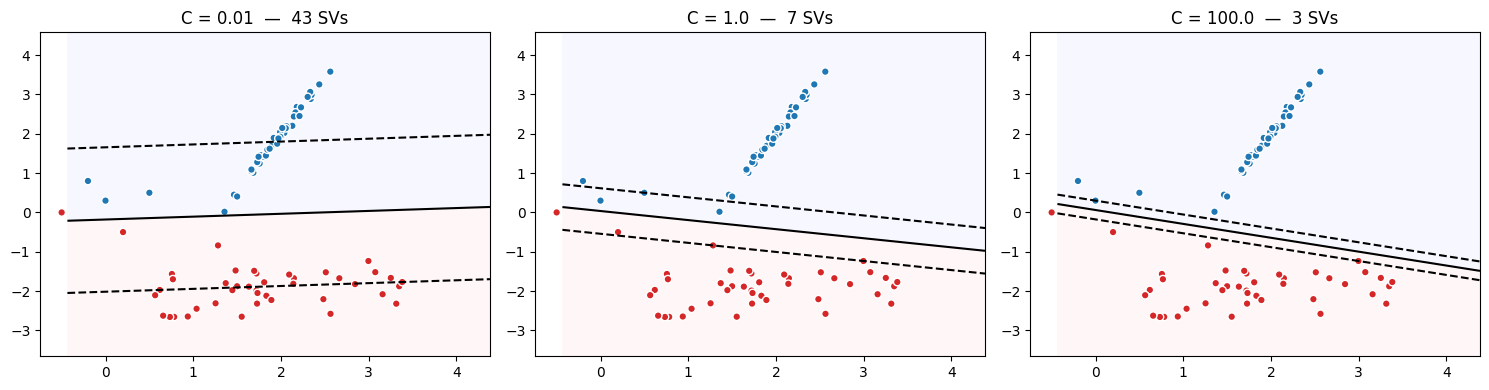

In [3]:
rng = np.random.default_rng(SEED)
X_noisy = X.copy()
# inject 5 points crossing into the other side, making the data not separable
X_noisy = np.vstack([X_noisy, np.array([[0.5, 0.5], [-0.5, 0.0], [0.0, 0.3], [0.2, -0.5], [-0.2, 0.8]])])
y_noisy = np.concatenate([y, [1, 0, 1, 0, 1]])
y_pm_noisy = np.where(y_noisy == 0, -1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, C in zip(axes, [0.01, 1.0, 100.0]):
    m = SVC(kernel='linear', C=C).fit(X_noisy, y_pm_noisy)
    Z = m.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z > 0, alpha=0.15, cmap=ListedColormap(['#ffcccc', '#ccccff']))
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='black', linestyles=['--', '-', '--'])
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy,
               cmap=ListedColormap(['tab:red', 'tab:blue']), edgecolor='white', s=30)
    ax.set_title(f'C = {C}  —  {len(m.support_)} SVs')
plt.tight_layout(); plt.show()

**Observation:** small C → wide margin, many SVs, more violations tolerated. Large C → narrow margin, fewer SVs, tries hard to classify every training point.

## 4. Non-linear data — `make_moons`

Linear SVM cannot separate two moons. RBF SVM can.

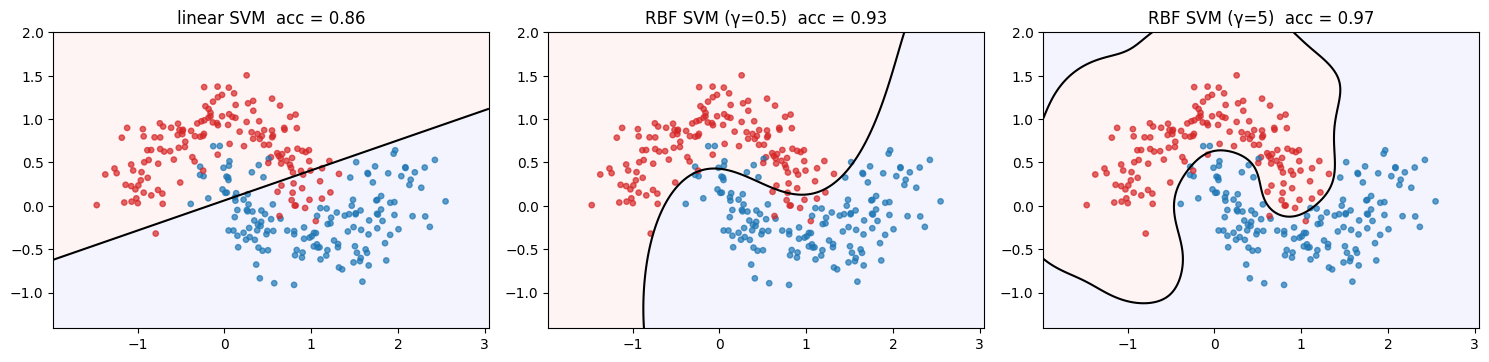

In [4]:
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=SEED)
ym_pm = np.where(ym == 0, -1, 1)

models = {
    'linear SVM':     SVC(kernel='linear', C=1.0).fit(Xm, ym_pm),
    'RBF SVM (γ=0.5)': SVC(kernel='rbf', C=1.0, gamma=0.5).fit(Xm, ym_pm),
    'RBF SVM (γ=5)':   SVC(kernel='rbf', C=1.0, gamma=5.0).fit(Xm, ym_pm),
}

xx, yy = np.meshgrid(
    np.linspace(Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5, 300),
    np.linspace(Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5, 300),
)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, m) in zip(axes, models.items()):
    Z = m.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z > 0, alpha=0.2, cmap=ListedColormap(['#ffcccc', '#ccccff']))
    ax.contour(xx, yy, Z, levels=[0], colors='black')
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap=ListedColormap(['tab:red', 'tab:blue']), s=15, alpha=0.7)
    acc = m.score(Xm, ym_pm)
    ax.set_title(f'{name}  acc = {acc:.2f}')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

γ = 0.5 → smooth boundary that nicely follows the moons. γ = 5 → boundary becomes very local and starts wrapping individual points.

## 5. Tune $C$ and $\gamma$ on Breast Cancer with GridSearchCV

In [5]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
}
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5).fit(X_train_s, y_train)
print(f'best params: {grid.best_params_}')
print(f'CV accuracy: {grid.best_score_:.4f}')
print(f'TEST accuracy: {grid.best_estimator_.score(X_test_s, y_test):.4f}')

best params: {'C': 10, 'gamma': 0.01}
CV accuracy: 0.9802
TEST accuracy: 0.9825


## 6. Compare with logistic regression — same dataset, same scaling

In [6]:
logreg = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_train_s, y_train)
linsvm = SVC(kernel='linear', C=1.0).fit(X_train_s, y_train)
rbfsvm = grid.best_estimator_

for name, m in [('LogisticRegression', logreg), ('linear SVM', linsvm), ('RBF SVM (tuned)', rbfsvm)]:
    print(f'{name:25s} test accuracy = {m.score(X_test_s, y_test):.4f}')

LogisticRegression        test accuracy = 0.9825
linear SVM                test accuracy = 0.9737
RBF SVM (tuned)           test accuracy = 0.9825


## 7. Summary

- SVM finds the maximum-margin hyperplane. Only the support vectors matter.
- $C$ tunes the soft margin: small = wide & tolerant, large = narrow & strict.
- Kernels (poly, RBF) let SVM handle non-linear data without manually engineering features.
- $C$ and $\gamma$ need to be tuned by CV. The defaults are rarely best.
- For high-dim sparse data (text) **linear** SVM is competitive with deep models.

**Next:** Phase 4 — neural networks, recommenders, PCA, model evaluation.